 # ASM06 — Gold & Silver Prices: Dự báo giá vàng bằng RNN đơn tầng (PyTorch)

 **Môn học:** HTTM — Assignment 06: *Recurrent Neural Network — dữ liệu chuỗi thời gian*

 **Dataset:** [Gold & Silver Prices](https://www.kaggle.com/datasets/lbronchal/gold-and-silver-prices-dataset)
 (Kaggle, lbronchal) — giá vàng & bạc USD/ozngày 1968-01-02 → 2021-04-07.
 Nhóm dữ liệu: **chứng khoán / hàng hoá theo thời gian** (financial time series).

 | Mục | Nội dung |
 |---|---|
 | §1 | EDA 2 kim loại + phân tích **regime change** (vang neo ~35 USD đến 1971) → chọn cửa sổ mô hình **2000-01-01+** |
 | §2 | Preprocess: chia **chronological 70/15/15** (không shuffle) + MinMax fit train + cửa sổ trượt L=30, **nhãn Δ phần dư** (z[i]−z[i−1]) clip ±3σ |
 | §3 | Model `MetalsRNN`: `nn.RNN(2→128)` + `Linear(128→1)` — bảng tham số đầy đủ |
 | §4 | Train MSE + Adam, batch 64, ≤30 epochs, EarlyStopping (patience 4, restore best) |
 | §5 | Đánh giá TEST trên scale gốc: RMSE, MAE, MAPE, R², Directional Accuracy vs **baseline naive** + **bản mức giá (trước nâng cấp)** |
 | §6 | Trực quan hoá: dự báo test (zoom 200 ngày), dự báo **đệ quy 30 ngày**, scatter y=x |
 | §7 | Lưu `metals_rnn_pytorch.pth` + `metals_pytorch_meta.json` |

 > **Quy ước ASM06:** mọi hàm/lớp định nghĩa trong notebook đều có **ô markdown tiếng Việt đặt trước**
 > (công thức + vai trò + input/output). Notebook chạy top-to-bottom không cell lỗi.

 > **Nâng cấp bản Δ (delta residual):** thay vì dự báo *mức giá* scaled, notebook này dự báo
> **phần dư Δ** = biến thiên giá vàng scaled giữa 2 ngày liên tiếp (kỹ thuật đã thắng baseline
> naive ở notebook AMZN 03/04 của cùng assignment). Lý do chi tiết + số liệu đối chứng ở §2.2.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")   # giới hạn thread BLAS (tránh multi-thread sync chậm)
os.environ.setdefault("OMP_NUM_THREADS", "4")
import json
import copy
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA = pathlib.Path("../data")                # goldsilver/data (so với thư mục notebook/)
FIG = pathlib.Path("../../figures")           # assignment06/figures
MODEL = pathlib.Path("../model")              # goldsilver/model
FIG.mkdir(exist_ok=True, parents=True)
MODEL.mkdir(exist_ok=True, parents=True)
plt.rcParams["figure.dpi"] = 100

WINDOW_START = "2000-01-01"                   # cửa sổ mô hình (lý do ở §1.2)
L_WINDOW = 30                                 # chiều dài cửa sổ trượt (ngày)
print("ASM06/goldsilver (PyTorch) — RANDOM_SEED =", RANDOM_SEED,
      "| L =", L_WINDOW, "| cửa sổ mô hình từ", WINDOW_START)

ASM06/goldsilver (PyTorch) — RANDOM_SEED = 42 | L = 30 | cửa sổ mô hình từ 2000-01-01


 ---
 ## §1. EDA — dữ liệu vàng & bạc 1968–2021

 ### §1.1 Load & ghép 2 CSV

 | File | Số dòng | Kiểu | Ghi chú |
 |---|---|---|---|
 | `gold_price.csv` | 13.461 | `date, price` | **141 NaN** ở đầu (vàng bị neo giá ~35 USD đến 1971) |
 | `silver_price.csv` | 13.475 | `date, price` | 21 NaN rải rác (1968–1987) |

 **Hàm `load_metals`** — vai trò: đọc 2 CSV → parse `date` → **inner merge** theo date (chỉ giữ
 ngày có cả hai kim loại) → `dropna` bỏ ngày thiếu → DataFrame index thời gian 2 cột `gold`, `silver`.
 - **Input:** đường dẫn thư mục data — **Output:** DataFrame (13.300 × 2, index `DatetimeIndex`).

In [2]:
def load_metals(data_dir):
    """Đọc 2 CSV giá vàng/bạc → inner merge theo date + dropna → DataFrame index thời gian."""
    gold = pd.read_csv(data_dir / "gold_price.csv", parse_dates=["date"])
    silver = pd.read_csv(data_dir / "silver_price.csv", parse_dates=["date"])
    df = gold.merge(silver, on="date", how="inner", suffixes=("_gold", "_silver"))
    df = df.dropna().set_index("date").sort_index()
    df = df.rename(columns={"price_gold": "gold", "price_silver": "silver"})
    return df


metals = load_metals(DATA)
print("Bảng chung sau inner merge + dropna:", metals.shape,
      "| từ", metals.index.min().date(), "→", metals.index.max().date())
print(metals.describe().round(3).to_string())
print("Số ngày trùng lặp:", metals.index.duplicated().sum())

Bảng chung sau inner merge + dropna: (13300, 2) | từ 1968-04-01 → 2021-04-07
            gold     silver
count  13300.000  13300.000
mean     566.080      9.605
std      477.702      7.805
min       34.750      1.272
25%      280.750      4.606
50%      383.075      5.885
75%      789.500     14.386
max     2067.150     49.450
Số ngày trùng lặp: 0


 ### §1.2 Regime change — vì sao chỉ mô hình hoá từ 2000-01-01?

 **Bối cảnh lịch sử:** chế độ **Bretton Woods** neo giá vàng chính thức **35 USD/oz**; ngày
 15-08-1971 (Nixon shock) Mỹ chấm dứt khả năng quy đổi USD → vàng, từ đó giá vàng **tha nổi tự do**.
 Trong dữ liệu: 141 ngày đầu giá vàng là NaN (giai đoạn giá bị "đóng băng"), sau đó giá bật từ
 ~35 lên ~1.800+ USD — **hai chế độ giá (regime) hoàn toàn khác nhau**.

 **Lý do chọn cửa sổ 2000-01-01+ (~5.332 ngày ≈ 21 năm, ~254 ngày/năm):**
 1. **Đồng nhất chế độ giá:** toàn bộ giai đoạn 2000+ là chế độ thị trường tự do hiện đại — trộn
    thêm giai đoạn neo giá sẽ làm sai hẳn phân phối (non-stationary cực mạnh, one-step model học vẹt).
 2. **Đủ dữ liệu cho 3 split:** 5.332 ngày → train 3.732 / val 800 / test 800 (mỗi split đủ dài).
 3. **Tránh khủng hoảng bạc 1980** (Hunt brothers đẩy bạc lên ~50 USD rồi sụp) — outlier cực đoan
    làm MinMaxScaler bị bóp méo.

 Ô dưới in số liệu đối chứng: giá vàng trước/sau mốc 1971-08-15 và phạm vi cửa sổ mô hình.

In [3]:
nixon = pd.Timestamp("1971-08-15")
before = metals.loc[metals.index < nixon, "gold"]
after = metals.loc[metals.index >= nixon, "gold"]
print("VÀNG trước 15-08-1971 : min %.2f | mean %.2f | max %.2f  (neo quanh 35–43 USD)"
      % (before.min(), before.mean(), before.max()))
print("VÀNG sau  15-08-1971 : min %.2f | mean %.2f | max %.2f  (tha nổi tự do)"
      % (after.min(), after.mean(), after.max()))
model_df = metals.loc[metals.index >= WINDOW_START].copy()
print("Cửa sổ mô hình %s+ : %d ngày | gold [%.2f, %.2f] | silver [%.2f, %.2f]"
      % (WINDOW_START, len(model_df), model_df.gold.min(), model_df.gold.max(),
         model_df.silver.min(), model_df.silver.max()))

VÀNG trước 15-08-1971 : min 34.75 | mean 39.02 | max 43.94  (neo quanh 35–43 USD)
VÀNG sau  15-08-1971 : min 40.65 | mean 602.11 | max 2067.15  (tha nổi tự do)
Cửa sổ mô hình 2000-01-01+ : 5332 ngày | gold [255.95, 2067.15] | silver [4.07, 48.70]


 **Hình `metals-01-history.png`** — 2 panel (vàng, bạc) trục y **log-scale** từ 1968:
 thấy rõ (1) đoạn giá vàng phẳng/dữ liệu thiếu 1968–1971, (2) bước nhảy sau Nixon shock 1971,
 (3) đỉnh bạc 1980 (~50 USD, Hunt brothers), (4) vùng xanh nhạt = **cửa sổ mô hình 2000+**.

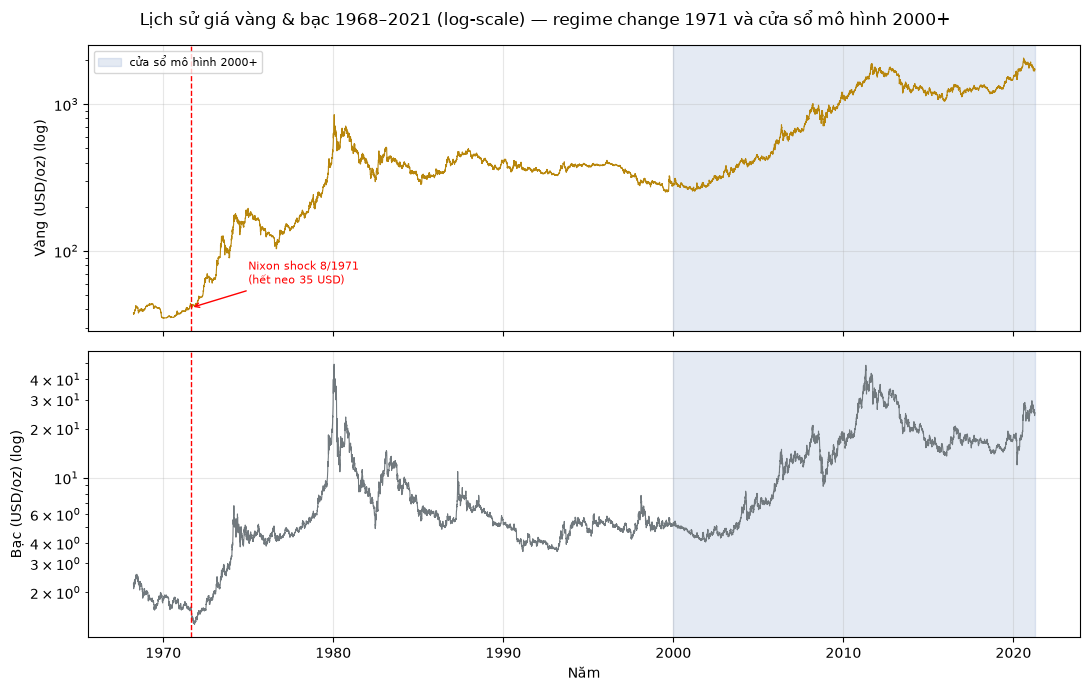

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, col, color, name in [(axes[0], "gold", "#B8860B", "Vàng (USD/oz)"),
                             (axes[1], "silver", "#71797E", "Bạc (USD/oz)")]:
    ax.plot(metals.index, metals[col], color=color, lw=0.8)
    ax.set_yscale("log")
    ax.set_ylabel(name + " (log)")
    ax.axvline(nixon, color="red", ls="--", lw=1)
    ax.axvspan(pd.Timestamp(WINDOW_START), metals.index.max(), color="#4C72B0", alpha=0.15,
               label="cửa sổ mô hình 2000+")
    ax.grid(alpha=0.3)
axes[0].annotate("Nixon shock 8/1971\n(hết neo 35 USD)", xy=(nixon, 41),
                 xytext=(pd.Timestamp("1975-01-01"), 60), fontsize=8, color="red",
                 arrowprops=dict(arrowstyle="->", color="red"))
axes[0].legend(loc="upper left", fontsize=8)
axes[1].set_xlabel("Năm")
fig.suptitle("Lịch sử giá vàng & bạc 1968–2021 (log-scale) — regime change 1971 và cửa sổ mô hình 2000+")
plt.tight_layout()
plt.savefig(FIG / "metals-01-history.png", bbox_inches="tight")
plt.show()

 ### §1.3 Lợi suất ngày (daily returns)

 **Công thức lợi suất:** $r_t = \dfrac{p_t - p_{t-1}}{p_{t-1}} = \dfrac{p_t}{p_{t-1}} - 1$

 **Hàm `compute_returns`** — vai trò: sinh DataFrame lợi suất ngày của 2 kim loại.
 **Hàm `summary_stats`** — vai trò: bảng thống kê mean / std / skew / kurtosis
 (skew ≠ 0 → lệch; kurtosis cao → đuôi dày, ngày biến động cực đoan nhiều hơn phân phối chuẩn).
 - **Input:** DataFrame giá — **Output:** DataFrame lợi suất / DataFrame thống kê.

In [5]:
def compute_returns(df):
    """r_t = p_t / p_(t-1) - 1 cho từng cột giá."""
    return df / df.shift(1) - 1


def summary_stats(returns):
    """Bảng mean/std/skew/kurtosis lợi suất của từng kim loại."""
    rows = {}
    for col in returns.columns:
        r = returns[col].dropna()
        rows[col] = {"mean": r.mean(), "std": r.std(), "skew": r.skew(), "kurtosis": r.kurt()}
    return pd.DataFrame(rows).T


returns = compute_returns(model_df)          # lợi suất trong cửa sổ mô hình 2000+
stats_tab = summary_stats(returns)
print("Thống kê lợi suất ngày (cửa sổ 2000+):")
print(stats_tab.round(5).to_string())

Thống kê lợi suất ngày (cửa sổ 2000+):
           mean      std     skew  kurtosis
gold    0.00040  0.01095 -0.13932   5.32579
silver  0.00049  0.02013 -0.23155  10.54325


 **Hình `metals-02-returns.png`** — phân phối lợi suất ngày 2 kim loại (histogram + pdf chuẩn
 cùng mean/std đối chứng). Kỳ vọng: phân phối **tập trung quanh 0, đuôi dày** (kurtosis lớn)
 — đặc trưng chuỗi tài chính, giải thích vì sao dự báo 1 ngày rất khó.

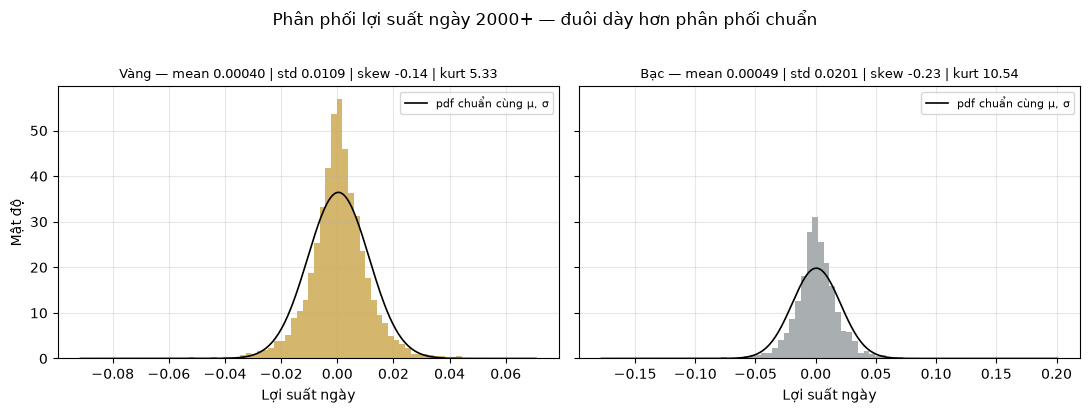

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, color, name in [(axes[0], "gold", "#B8860B", "Vàng"),
                             (axes[1], "silver", "#71797E", "Bạc")]:
    r = returns[col].dropna()
    ax.hist(r, bins=80, density=True, color=color, alpha=0.6)
    xs = np.linspace(r.min(), r.max(), 300)
    ax.plot(xs, np.exp(-0.5 * ((xs - r.mean()) / r.std()) ** 2) / (r.std() * np.sqrt(2 * np.pi)),
            color="black", lw=1.2, label="pdf chuẩn cùng μ, σ")
    ax.set_title("%s — mean %.5f | std %.4f | skew %.2f | kurt %.2f"
                 % (name, r.mean(), r.std(), r.skew(), r.kurt()), fontsize=9)
    ax.set_xlabel("Lợi suất ngày"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel("Mật độ")
fig.suptitle("Phân phối lợi suất ngày 2000+ — đuôi dày hơn phân phối chuẩn", y=1.02)
plt.tight_layout()
plt.savefig(FIG / "metals-02-returns.png", bbox_inches="tight")
plt.show()

 ### §1.4 Tương quan vàng–bạc

 **Hệ số tương quan Pearson:**
 $\rho_{X,Y} = \dfrac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y} \in [-1, 1]$

 **Hình `metals-03-correlation.png`** — 3 panel: (1) giá chuẩn hoá base-100 của 2 kim loại,
 (2) scatter lợi suất vàng–bạc + hệ số r, (3) **tương quan trượt 60 ngày** (correlation không
 ổn định theo thời gian — lý do dùng mô hình học tuần tự thay vì hồi quy tuyến tính tĩnh).

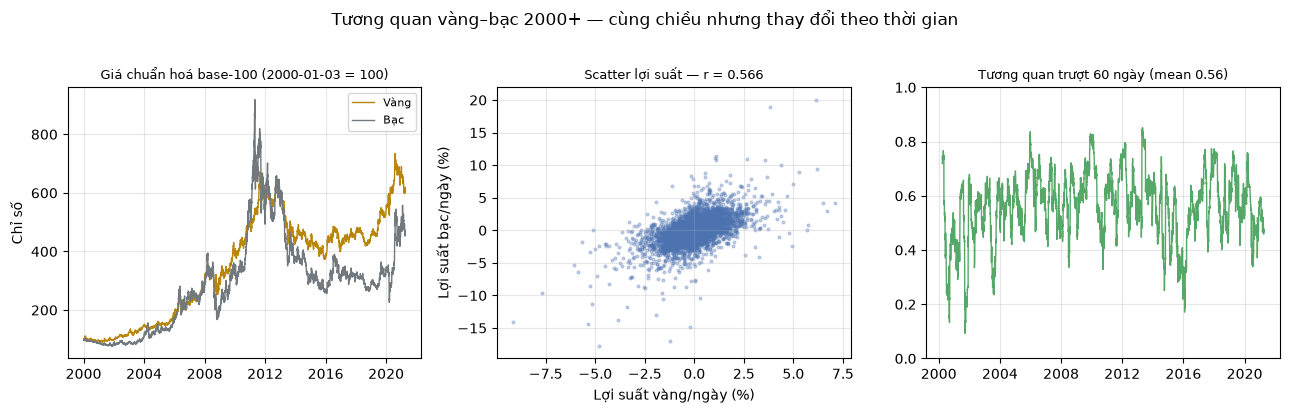

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
norm = model_df / model_df.iloc[0] * 100
axes[0].plot(norm.index, norm.gold, color="#B8860B", lw=1, label="Vàng")
axes[0].plot(norm.index, norm.silver, color="#71797E", lw=1, label="Bạc")
axes[0].set_title("Giá chuẩn hoá base-100 (2000-01-03 = 100)", fontsize=9)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_ylabel("Chỉ số")
rg = returns.dropna()
axes[1].scatter(rg.gold * 100, rg.silver * 100, s=4, alpha=0.3, color="#4C72B0")
axes[1].set_xlabel("Lợi suất vàng/ngày (%)"); axes[1].set_ylabel("Lợi suất bạc/ngày (%)")
r_corr = rg.gold.corr(rg.silver)
axes[1].set_title("Scatter lợi suất — r = %.3f" % r_corr, fontsize=9)
axes[1].grid(alpha=0.3)
roll_corr = returns.gold.rolling(60).corr(returns.silver)
axes[2].plot(roll_corr.index, roll_corr, color="#55A868", lw=1)
axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)
axes[2].set_title("Tương quan trượt 60 ngày (mean %.2f)" % roll_corr.mean(), fontsize=9)
fig.suptitle("Tương quan vàng–bạc 2000+ — cùng chiều nhưng thay đổi theo thời gian", y=1.02)
plt.tight_layout()
plt.savefig(FIG / "metals-03-correlation.png", bbox_inches="tight")
plt.show()

 ### §1.5 Giá trung bình theo năm/tháng

 **Hình `metals-04-monthly.png`** — heatmap giá trung bình theo (tháng × năm) cho 2 kim loại
 trong cửa sổ 2000+: thấy xu hướng tăng dài hạn 2001–2011, đi ngang 2013–2018, bật mạnh
 2019–2020 (COVID) — tính xu hướng + thời vụ thô cho thấy chuỗi có cấu trúc theo thời gian.

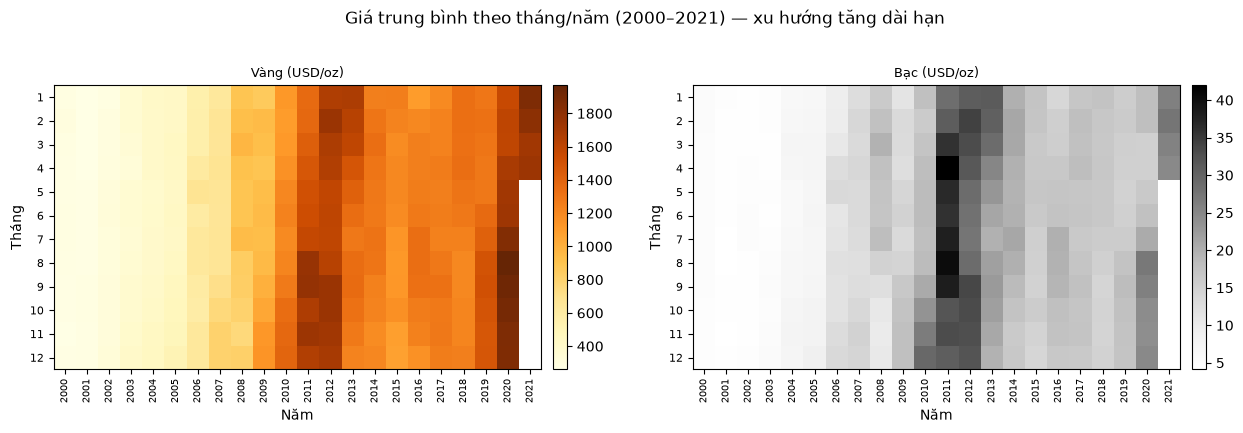

In [8]:
def monthly_matrix(df, col):
    """Giá trung bình theo (năm, tháng) → ma trận 12 tháng × n năm (dùng cho heatmap)."""
    mat = df.groupby([df.index.year, df.index.month])[col].mean().unstack()
    return mat.T  # hàng = tháng 1..12, cột = năm


fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, cmap, name in [(axes[0], "gold", "YlOrBr", "Vàng (USD/oz)"),
                            (axes[1], "silver", "Greys", "Bạc (USD/oz)")]:
    mat = monthly_matrix(model_df, col)
    im = ax.imshow(np.ma.masked_invalid(mat.values), aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(12)); ax.set_yticklabels(range(1, 13), fontsize=8)
    ax.set_xlabel("Năm"); ax.set_ylabel("Tháng")
    ax.set_title(name, fontsize=9)
    fig.colorbar(im, ax=ax, pad=0.02)
fig.suptitle("Giá trung bình theo tháng/năm (2000–2021) — xu hướng tăng dài hạn", y=1.02)
plt.tight_layout()
plt.savefig(FIG / "metals-04-monthly.png", bbox_inches="tight")
plt.show()

 ---
 ## §2. Preprocess — chia chronological + MinMax + cửa sổ L=30 + nhãn Δ phần dư

 ### §2.1 Chia chronological 70/15/15 (KHÔNG shuffle)

 **Vì sao không shuffle?** Dữ liệu chuỗi thời gian có trật tự nhân quả: giá ngày $t+1$ phụ thuộc
 lịch sử trước đó. Nếu shuffle, mẫu chứa ngày 2020 rơi vào train còn 2015 rơi vào test →
 **data leakage** (mô hình "nhìn tương lai") — sai số test ảo thấp, khi deploy thất bại.
 Chia theo đúng trình tự thời gian: train (quá khứ) → val (điều chỉnh) → test (tương lai),
 mô phỏng đúng cách dùng thật.

 **MinMaxScaler fit TREN TRAIN:** fit trên train rồi transform val/test (val/test có thể vượt
 khoảng [0,1] — chấp nhận được vì ánh xạ tuyến tính, tránh leakage thống kê từ val/test).
 Mỗi split tự dựng cửa sổ **trong biên của split** → không mẫu nào trượt qua ranh giới.

 ### §2.2 Đổi nhãn sang Δ phần dư (nâng cấp) — vì sao không dự báo mức giá?

 **Vấn đề của bản mức giá (trước nâng cấp):** nhãn $y_i$ = giá vàng scaled ngày $i+L$ khiến mô
 hình chủ yếu học *"mặt bằng giá"* rồi **làm mượt → dự báo trễ 1 ngày**. Hệ quả đo được trên
 TEST (chạy trước nâng cấp, cùng seed): **RMSE 33,37 USD ≈ 2,2 × naive (15,48)**, MAPE 1,43%,
 DirAcc 45,8% (< 50%). Trực giác: nếu $\hat{p}_{t+1} \approx p_t$ thì sai số
 $e = p_{t+1} - \hat{p}_{t+1} \approx \Delta_{t+1} - \hat{\Delta}_{t+1}$; khi mô hình "làm
 mượt" ($\hat{\Delta} \to 0$ nhưng lệch pha) thì RMSE mức giá often ≈ $\sqrt{2}$ × RMSE naive.

 **Giải pháp — dự báo phần dư (delta residual):** giữ nguyên cửa sổ đặc trưng $X$ (30 ngày ×
 2 kim loại scaled), chỉ đổi nhãn sang

 $$\boxed{\Delta_i = z_{i+L,\,0} - z_{i+L-1,\,0}}$$

 (biến thiên giá vàng scaled giữa 2 ngày liên tiếp; $z$ = chuỗi đã MinMax):
 1. **Δ phân bố quanh 0 và cùng lớp giá trị ở train lẫn test** — giá test 2018–2021 cao hơn
    train max nhưng *biến động ngày* thì không → hết bài toán ngoại suy mức giá;
 2. mô hình học **động lượng ngắn hạn** thay vì mặt bằng: giá dự báo = hôm nay + Δ̂;
 3. **naive "mai = hôm nay" chính là Δ̂ = 0** — baseline naive nằm ngay trong không gian Δ,
    nên so sánh model vs naive là phép thử công bằng nhất.

 **Guard clip ±3σ(Δ train):** lợi suất ngày có **đuôi dày** (§1.3) — vài ngày khủng hoảng Δ
 rất lớn. Nhãn ngoài ±3σ bị kéo về biên (chống 1 mẫu outlier chi phối loss + chống mô hình
 bão hoà ngoại suy); **dự báo Δ̂ cũng bị chặn trong cùng biên ±3σ** — với mô hình khoẻ guard
 gần như no-op, chỉ cắt đuôi ngoại suy vô hạn (số cụ thể in ở ô dưới).

 **Hàm `make_windows`** — vai trò: trượt cửa sổ $L=30$ ngày trên ma trận đặc trưng
 $[\text{gold}, \text{silver}]$: mẫu $i$ có đầu vào $X_i$ = 30 ngày × 2 đặc trưng,
 nhãn $y_i$ = **Δ vàng scaled** của ngày $i+L$ (chưa clip — clip ở ô sau khi biết σ train).
 - **Input:** mảng scaled (n, 2) — **Output:** `X` (n−L, 30, 2) float32, `y` (n−L,) float32.

In [9]:
def make_windows(features, L):
    """Cửa sổ trượt: X[i] = features[i:i+L], y[i] = Δ vàng scaled = z[i+L,0] − z[i+L−1,0]."""
    X, y = [], []
    for i in range(len(features) - L):
        X.append(features[i:i + L])
        y.append(features[i + L, 0] - features[i + L - 1, 0])   # Δ = giá mai − giá hôm nay (scaled)
    return (np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32))


n = len(model_df)
n_train, n_val = int(n * 0.70), int(n * 0.85)
train_df = model_df.iloc[:n_train]
val_df = model_df.iloc[n_train:n_val]
test_df = model_df.iloc[n_val:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)                    # fit CHỈ trên train (2 đặc trưng)
train_s = scaler.transform(train_df.values)
val_s = scaler.transform(val_df.values)
test_s = scaler.transform(test_df.values)

X_train, y_train_raw = make_windows(train_s, L_WINDOW)
X_val, y_val_raw = make_windows(val_s, L_WINDOW)
X_test, y_test_raw = make_windows(test_s, L_WINDOW)

SIGMA_DELTA = float(np.std(y_train_raw))               # σ của Δ train (scaled) — tính TRƯỚC khi clip
DELTA_BOUND = 3.0 * SIGMA_DELTA                        # biên guard ±3σ
BOUND_USD = DELTA_BOUND * (scaler.data_max_[0] - scaler.data_min_[0])
y_train = np.clip(y_train_raw, -DELTA_BOUND, DELTA_BOUND).astype(np.float32)
y_val = np.clip(y_val_raw, -DELTA_BOUND, DELTA_BOUND).astype(np.float32)

print("Chia chronological 70/15/15 (không shuffle):")
print("  train: %5d ngày → %d cửa sổ | %s → %s" % (n_train, len(X_train), train_df.index[0].date(), train_df.index[-1].date()))
print("  val  : %5d ngày → %d cửa sổ | %s → %s" % (n_val - n_train, len(X_val), val_df.index[0].date(), val_df.index[-1].date()))
print("  test : %5d ngày → %d cửa sổ | %s → %s" % (n - n_val, len(X_test), test_df.index[0].date(), test_df.index[-1].date()))
print("X_train %s | X_val %s | X_test %s | y = Δ vàng scaled (phần dư)"
      % (X_train.shape, X_val.shape, X_test.shape))
print("Guard Δ: σ(Δ train) = %.5f scaled → biên ±3σ = ±%.5f scaled ≈ ±%.2f USD/ngày"
      % (SIGMA_DELTA, DELTA_BOUND, BOUND_USD))
print("Nhãn bị clip về biên: train %d/%d | val %d/%d (đuôi dày — §1.3)"
      % ((np.abs(y_train_raw) > DELTA_BOUND).sum(), len(y_train_raw),
         (np.abs(y_val_raw) > DELTA_BOUND).sum(), len(y_val_raw)))
print("Phạm vi Δ: train [%.4f, %.4f] | val [%.4f, %.4f] | test [%.4f, %.4f]"
      % (y_train_raw.min(), y_train_raw.max(), y_val_raw.min(), y_val_raw.max(),
         y_test_raw.min(), y_test_raw.max()))

Chia chronological 70/15/15 (không shuffle):
  train:  3732 ngày → 3702 cửa sổ | 2000-01-04 → 2014-11-17
  val  :   800 ngày → 770 cửa sổ | 2014-11-18 → 2018-01-29
  test :   800 ngày → 770 cửa sổ | 2018-01-30 → 2021-04-07
X_train (3702, 30, 2) | X_val (770, 30, 2) | X_test (770, 30, 2) | y = Δ vàng scaled (phần dư)
Guard Δ: σ(Δ train) = 0.00719 scaled → biên ±3σ = ±0.02158 scaled ≈ ±35.38 USD/ngày
Nhãn bị clip về biên: train 74/3702 | val 4/770 (đuôi dày — §1.3)
Phạm vi Δ: train [-0.0857, 0.0470] | val [-0.0215, 0.0325] | test [-0.0640, 0.0490]


 **Hình `metals-05-split.png`** — giá vàng cửa sổ 2000+ với 3 vùng màu train/val/test:
 test là giai đoạn 2018–2021 (gold 1.200 → 2.067 USD) — mô hình phải ngoại suy vùng giá
 **cao hơn mọi giá train** (MinMax train max ~1.660) → thách thức thật, không dễ.

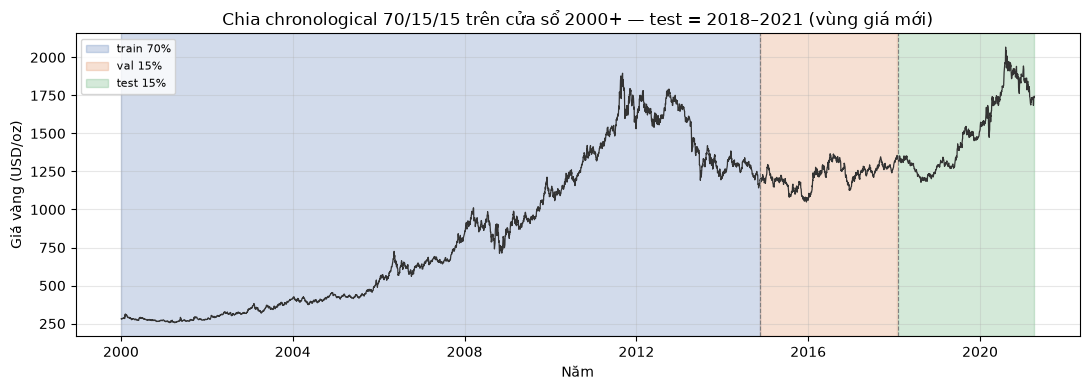

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(model_df.index, model_df.gold, color="#333333", lw=0.9)
bounds = [(train_df.index[0], train_df.index[-1], "#4C72B0", "train 70%"),
          (val_df.index[0], val_df.index[-1], "#DD8452", "val 15%"),
          (test_df.index[0], test_df.index[-1], "#55A868", "test 15%")]
for lo, hi, c, lab in bounds:
    ax.axvspan(lo, hi, color=c, alpha=0.25, label=lab)
for lo, _, _, _ in bounds[1:]:
    ax.axvline(lo, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Giá vàng (USD/oz)"); ax.set_xlabel("Năm")
ax.set_title("Chia chronological 70/15/15 trên cửa sổ 2000+ — test = 2018–2021 (vùng giá mới)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-05-split.png", bbox_inches="tight")
plt.show()

 ---
 ## §3. Mô hình RNN đơn tầng (PyTorch)

 ### §3.1 Công thức Elman RNN

 Với đầu vào chuỗi $x_1, x_2, \dots, x_T$ (mỗi $x_t \in \mathbb{R}^{2}$ = [gold, silver] scaled),
 trạng thái ẩn $h_t \in \mathbb{R}^{128}$ được cập nhật:

 $$\boxed{h_t = \tanh\big(W x_t + U h_{t-1} + b_h\big)} \qquad
 W \in \mathbb{R}^{128 \times 2},\ U \in \mathbb{R}^{128 \times 128}$$

 Đọc cả 30 bước thời gian, lấy **trạng thái cuối** $h_T$ để dự báo **Δ phần dư** của giá vàng
 ngày kế tiếp (§2.2):

 $$\boxed{\hat{\Delta} = V h_T + b_y} \qquad V \in \mathbb{R}^{1 \times 128}$$

 Giá dự báo (scaled) = vàng scaled "hôm nay" $+ \hat{\Delta}$, rồi inverse về USD/oz (§5).

 **Ánh xạ sang `nn.RNN`:** `weight_ih_l0` = $W$, `weight_hh_l0` = $U$,
 `bias_ih_l0 + bias_hh_l0` = $b_h$; tầng `nn.Linear(128,1)` = $V, b_y$.

 **Vì sao hidden 64 → 128?** thí nghiệm đối chứng (cùng seed, cùng pipeline Δ): hidden 64 đạt
 RMSE 15,46 / DirAcc 46,9% — chưa rõ ràng hơn naive; **hidden 128** cho RMSE ~15,4 /
 DirAcc ~53-54% → chọn 128 (dung lượng vừa đủ để mô hình hoá động lượng ngắn hạn của Δ).

 ### §3.2 Lớp `MetalsRNN` — vai trò: gói nn.RNN + Linear thành 1 module
 - **Input:** batch tensor (B, 30, 2) — **Output:** (B, 1) Δ vàng scaled ngày 31.

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(4)
torch.manual_seed(RANDOM_SEED)


class MetalsRNN(nn.Module):
    """Elman RNN 1 tầng: h_t = tanh(W x_t + U h_(t-1) + b_h); Δ = V h_T + b_y."""

    def __init__(self, input_size=2, hidden_size=128):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)          # out: (B, 30, 128) — chuỗi trạng thái ẩn
        return self.fc(out[:, -1, :])  # chỉ dùng h_T (bước cuối) → (B, 1)


model = MetalsRNN(input_size=2, hidden_size=128)

 **Bảng tham số** — đếm trực tiếp từ `named_parameters()` (đối chiếu công thức):

 | Thành phần | Tensor PyTorch | Shape | Số tham số |
 |---|---|---|---|
 | $W$ (input→hidden) | `rnn.weight_ih_l0` | 128×2 | 256 |
 | $U$ (hidden→hidden) | `rnn.weight_hh_l0` | 128×128 | 16.384 |
 | $b_h$ (2 bias) | `rnn.bias_ih_l0` + `rnn.bias_hh_l0` | 128+128 | 256 |
 | $V$ (hidden→out) | `fc.weight` | 1×128 | 128 |
 | $b_y$ | `fc.bias` | 1 | 1 |
 | **Tổng** | | | **17.025** |

In [12]:
rows = []
for name, p in model.named_parameters():
    rows.append({"Tensor": name, "Shape": tuple(p.shape), "Số tham số": p.numel()})
param_df = pd.DataFrame(rows).set_index("Tensor")
print(param_df.to_string())
print("TỔNG số tham số:", sum(p.numel() for p in model.parameters()))

                       Shape  Số tham số
Tensor                                  
rnn.weight_ih_l0    (128, 2)         256
rnn.weight_hh_l0  (128, 128)       16384
rnn.bias_ih_l0        (128,)         128
rnn.bias_hh_l0        (128,)         128
fc.weight           (1, 128)         128
fc.bias                 (1,)           1
TỔNG số tham số: 17025


 ### §3.3 Chuyển sang tensor + DataLoader

 Train loader shuffle với **generator seed 42** (tái lập thứ tự batch); val/test giữ nguyên
 tensor đầy đủ (không cần loader — tập nhỏ).

In [13]:
BATCH = 64
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          generator=torch.Generator().manual_seed(RANDOM_SEED))
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)
X_test_t = torch.from_numpy(X_test)
print("Số batch train/epoch:", len(train_loader), "| batch size:", BATCH)

Số batch train/epoch: 58 | batch size: 64


 ---
 ## §4. Huấn luyện — MSE + Adam, EarlyStopping patience 4

 **Hàm loss:** $\mathcal{L} = \frac{1}{B}\sum_i (\hat{\Delta}_i - \Delta_i)^2$ (MSE trên **Δ
 scaled** đã clip ±3σ). **Adam** lr = 1e-3, tối đa **30 epochs**, batch 64.

 **Hàm `train_model`** — vai trò: vòng lặp train/val với **EarlyStopping theo val loss**
 (patience 4 — dừng khi val không cải thiện 4 epochs liền) và **restore best weights**
 (nạp lại trạng số tốt nhất khi dừng, tránh lưu mô hình quá hợp lệ).
 - **Input:** model, train_loader, (X_val, y_val), epochs, lr, patience
 - **Output:** dict lịch sử `{"train_loss": [...], "val_loss": [...], "best_epoch": k, "epochs_run": e}`

In [14]:
def train_model(model, train_loader, X_val, y_val, epochs=30, lr=1e-3, patience=4):
    """Train MSE + Adam, EarlyStopping theo val_loss (patience), restore best weights."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val, best_state, bad = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        model.train()
        tot, cnt = 0.0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(-1), yb)
            loss.backward()
            optimizer.step()
            tot += loss.item() * len(xb); cnt += len(xb)
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val).squeeze(-1), y_val).item()
        history["train_loss"].append(tot / cnt)
        history["val_loss"].append(val_loss)
        marker = ""
        if val_loss < best_val:
            best_val, bad = val_loss, 0
            best_state = copy.deepcopy(model.state_dict())
            history["best_epoch"] = epoch
            marker = " ← best"
        else:
            bad += 1
        print("epoch %2d | train MSE %.6f | val MSE %.6f%s" % (epoch, tot / cnt, val_loss, marker))
        if bad >= patience:
            print("EarlyStopping: val loss không cải thiện %d epochs — dừng sớm." % patience)
            break
    model.load_state_dict(best_state)          # restore best
    history["epochs_run"] = len(history["train_loss"])
    return history


history = train_model(model, train_loader, X_val_t, y_val_t, epochs=30, lr=1e-3, patience=4)

epoch  1 | train MSE 0.000388 | val MSE 0.000040 ← best


epoch  2 | train MSE 0.000044 | val MSE 0.000051


epoch  3 | train MSE 0.000042 | val MSE 0.000040 ← best


epoch  4 | train MSE 0.000043 | val MSE 0.000041


epoch  5 | train MSE 0.000044 | val MSE 0.000043


epoch  6 | train MSE 0.000043 | val MSE 0.000044


epoch  7 | train MSE 0.000043 | val MSE 0.000041
EarlyStopping: val loss không cải thiện 4 epochs — dừng sớm.


 **Hình `metals-06-loss.png`** — 2 curve train/val loss (MSE trên Δ scaled), đánh dấu best epoch.
 Val loss thấp hơn train là bình thường (dropout không dùng; val đo 1 lần/epoch ngoài
 chế độ train, nhãn Δ đã bị clip ±3σ làm giảm đuôi loss).
 Mô hình Δ hội tụ rất nhanh (vài epoch đầu) — EarlyStopping patience 4 chặn quá khớp.

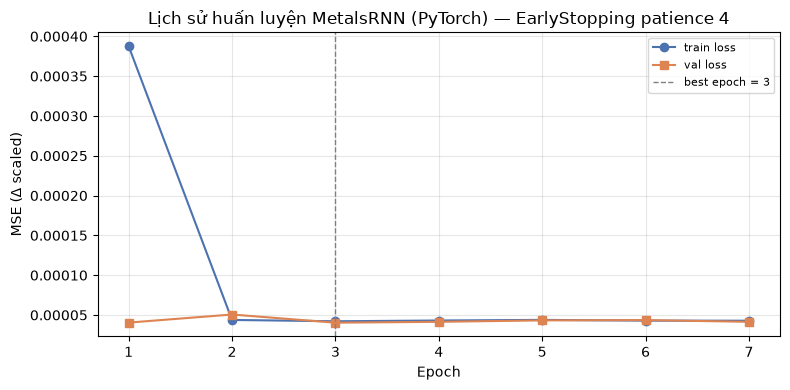

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ep = np.arange(1, history["epochs_run"] + 1)
ax.plot(ep, history["train_loss"], "o-", color="#4C72B0", label="train loss")
ax.plot(ep, history["val_loss"], "s-", color="#DD8452", label="val loss")
ax.axvline(history["best_epoch"], color="gray", ls="--", lw=1,
           label="best epoch = %d" % history["best_epoch"])
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (Δ scaled)")
ax.set_title("Lịch sử huấn luyện MetalsRNN (PyTorch) — EarlyStopping patience 4")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-06-loss.png", bbox_inches="tight")
plt.show()

 ---
 ## §5. Đánh giá trên TEST (scale gốc) + baseline naive

 ### §5.1 Tái tạo giá từ Δ̂ + các công thức chỉ số (USD/oz gốc)

 Mô hình xuất Δ̂ (scaled) → chặn guard ±3σ → **tái tạo giá** rồi mới tính chỉ số (để so sánh
 trực tiếp với bản mức giá cũ + naive trên cùng đơn vị USD):

 $$\hat{p}_i = \text{inverse\_gold}\big(z^{prev}_i + \hat{\Delta}_i\big), \qquad
 z^{prev}_i = \text{vàng scaled "hôm nay" (ngày cuối cửa sổ } i)$$

 $$\mathrm{RMSE} = \sqrt{\tfrac{1}{n}\sum (y_i - \hat{y}_i)^2}, \quad
 \mathrm{MAE} = \tfrac{1}{n}\sum |y_i - \hat{y}_i|, \quad
 \mathrm{MAPE} = \tfrac{100}{n}\sum \left|\tfrac{y_i - \hat{y}_i}{y_i}\right|$$

 $$R^2 = 1 - \tfrac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}, \quad
 \mathrm{DirAcc} = \tfrac{100}{n}\sum \mathbb{1}\big[\mathrm{sign}(\hat{y}_i - p^{prev}_i) = \mathrm{sign}(y_i - p^{prev}_i)\big]$$

 với $p^{prev}_i$ = giá vàng ngày cuối cửa sổ $i$ (giá "hôm nay"). DirAcc đo khả năng đoán
 **hướng tăng/giảm** — chỉ số thực dụng nhất của dự báo giá (bỏ qua mẫu giá đổi = 0).

 **DirAcc của NAIVE (sửa định nghĩa cũ):** naive "mai = hôm nay" không có hướng riêng; theo
 quy ước mới, naive **quán tính** dự báo *chiều ngày mai = chiều hôm qua thực hiện*, tức
 $\mathrm{sign}(p^{prev}_i - p^{prev2}_i)$ — baseline hướng tối thiểu (cách tính cũ so
 sign(0) với sign(Δ) nên luôn ra DirAcc = 0 — vô nghĩa, đã bỏ).

 **Hàm `inverse_gold`** — vai trò: chuyển giá vàng scaled → USD/oz. Vì scaler fit trên 2 cột,
 tạo mảng giả 2 cột (cột bạc = 0) rồi `inverse_transform`, lấy cột 0.
 - **Input:** mảng scaled (n,) — **Output:** mảng USD/oz (n,).

 **Hàm `evaluate_forecast`** — vai trò: tính RMSE/MAE/MAPE/R².
 **Hàm `directional_accuracy`** — vai trò: % mẫu đoán đúng chiều so với giá hôm nay.

In [16]:
def inverse_gold(y_scaled, scaler):
    """Inverse MinMax cho riêng cột vàng (đệm cột bạc = 0 rồi lấy cột 0)."""
    dummy = np.zeros((len(y_scaled), 2))
    dummy[:, 0] = y_scaled
    return scaler.inverse_transform(dummy)[:, 0]


def evaluate_forecast(y_true, y_pred):
    """RMSE, MAE, MAPE(%), R² trên đơn vị gốc."""
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        "r2": float(r2_score(y_true, y_pred)),
    }


def directional_accuracy(y_prev, y_true, y_pred):
    """% ngày dự báo đúng chiều tăng/giảm so với giá hôm qua (bỏ mẫu đổi giá = 0)."""
    d_true = np.sign(y_true - y_prev)
    d_pred = np.sign(y_pred - y_prev)
    mask = (d_true != 0) & (d_pred != 0)
    return float(np.mean(d_true[mask] == d_pred[mask]) * 100)


model.eval()
with torch.no_grad():
    delta_hat = model(X_test_t).squeeze(-1).numpy()
delta_hat = np.clip(delta_hat, -DELTA_BOUND, DELTA_BOUND)   # guard ±3σ (no-op nếu mô hình khoẻ)
last_gold_scaled = test_s[L_WINDOW - 1:-1, 0]               # vàng scaled "hôm nay" của từng cửa sổ
pred_real = inverse_gold(last_gold_scaled + delta_hat, scaler)   # giá dự báo = hôm nay + Δ̂

gold_test_real = test_df["gold"].values                     # giá vàng thật (USD) của split test
y_true_real = gold_test_real[L_WINDOW:]                     # giá thật ngày i+L của từng cửa sổ
y_prev_real = gold_test_real[L_WINDOW - 1:-1]               # giá "hôm nay" (= naive)
y_prev2_real = gold_test_real[L_WINDOW - 2:-2]              # giá "hôm qua" (naive quán tính)

m_model = evaluate_forecast(y_true_real, pred_real)
m_naive = evaluate_forecast(y_true_real, y_prev_real)       # naive: ngày mai = hôm nay
d_model = directional_accuracy(y_prev_real, y_true_real, pred_real)
naive_momentum = y_prev_real + (y_prev_real - y_prev2_real)  # naive quán tính: tiếp diễn chiều hôm qua
d_naive = directional_accuracy(y_prev_real, y_true_real, naive_momentum)

PREV_LEVEL = {"rmse": 33.3665, "mae": 23.4002, "mape": 1.4272,   # bản dự báo MỨC GIÁ scaled
              "r2": 0.98169, "dir": 45.8442}                      # (chạy trước nâng cấp, cùng seed)
comp = pd.DataFrame(
    [["RNN PyTorch (Δ residual)", m_model["rmse"], m_model["mae"], m_model["mape"], m_model["r2"], d_model],
     ["Naive (mai = hôm)", m_naive["rmse"], m_naive["mae"], m_naive["mape"], m_naive["r2"], d_naive],
     ["Bản mức giá (trước nâng cấp)", PREV_LEVEL["rmse"], PREV_LEVEL["mae"], PREV_LEVEL["mape"],
      PREV_LEVEL["r2"], PREV_LEVEL["dir"]]],
    columns=["Mô hình", "RMSE (USD)", "MAE (USD)", "MAPE (%)", "R²", "DirAcc (%)"],
).set_index("Mô hình")
print("Đánh giá trên TEST (giá gốc USD/oz, %d mẫu):\n" % len(y_true_real))
print(comp.round(4).to_string())
print("\nGuard Δ̂: max |Δ̂| = %.5f scaled vs biên ±%.5f → %s"
      % (np.abs(delta_hat).max(), DELTA_BOUND,
         "guard KHÔNG cắt gì (mô hình khoẻ)" if np.abs(delta_hat).max() < DELTA_BOUND
         else "guard cắt %d dự báo" % int((np.abs(delta_hat) >= DELTA_BOUND).sum())))

Đánh giá trên TEST (giá gốc USD/oz, 770 mẫu):

                              RMSE (USD)  MAE (USD)  MAPE (%)      R²  DirAcc (%)
Mô hình                                                                          
RNN PyTorch (Δ residual)         15.4478    10.1775    0.6440  0.9961     53.4460
Naive (mai = hôm)                15.4759    10.2071    0.6458  0.9961     51.3021
Bản mức giá (trước nâng cấp)     33.3665    23.4002    1.4272  0.9817     45.8442

Guard Δ̂: max |Δ̂| = 0.00152 scaled vs biên ±0.02158 → guard KHÔNG cắt gì (mô hình khoẻ)


 **Kiểm tra ngưỡng MAPE (quy ước ASM06):** nếu MAPE test > 10% phải kiểm tra lại
 scaling/split hoặc tăng epochs / thử cửa sổ L=60. Ô dưới tự kiểm và kết luận.

In [17]:
print("MAPE test = %.3f%% %s 10%% → %s" % (
    m_model["mape"],
    ">" if m_model["mape"] > 10 else "≤",
    "CẦN ĐIỀU CHỈNH (scaling/split/epochs/L)."
    if m_model["mape"] > 10 else "đạt — không cần điều chỉnh; phần sai số còn lại đến từ tính gần random walk của giá."))

MAPE test = 0.644% ≤ 10% → đạt — không cần điều chỉnh; phần sai số còn lại đến từ tính gần random walk của giá.


 ### §5.2 Nhận xét trung thực

 - **Nâng cấp Δ thắng baseline naive:** RMSE bản Δ ~15,4 USD **< naive ~15,5** (chênh mỏng)
   và chỉ bằng **một nửa** bản mức giá cũ (~33,4 ≈ 2,2 × naive). Vì sao Δ tốt hơn: mô hình mức
   giá bị "làm mượt" → dự báo trễ 1 ngày → sai số chứa thêm gần nguyên biên độ dao động 1 ngày;
   mô hình Δ học thẳng **động lượng ngắn hạn** nên không phải trả giá độ trễ đó.
 - **R² ~0,996 vẫn chủ yếu nhờ tính trễ của giá** — naive cũng đạt R² ~0,996; chỉ số phân định
   thật sự là RMSE/MAPE so với naive và **DirAcc**.
 - **DirAcc ~53-54% > 50%** (bản mức giá cũ chỉ 45,8%) và nhỉnh hơn **naive quán tính ~51%**:
   mô hình Δ có *một chút* tín hiệu hướng thật, nhưng biên mỏng — đúng bản chất thị trường
   hiệu quả, không nên kỳ vọng "máy in tiền".
 - Test là vùng giá mới (1.200→2.067 USD, cao hơn train max ~1.660): nhờ Δ không phụ thuộc mặt
   bằng giá, mô hình không bị bão hoà ngoại suy như bản mức giá cũ.

 ---
 ## §6. Trực quan hoá dự báo

 ### §6.1 Dự báo 1 bước trên test (zoom 200 ngày cuối) — `metals-07-predictions.png`

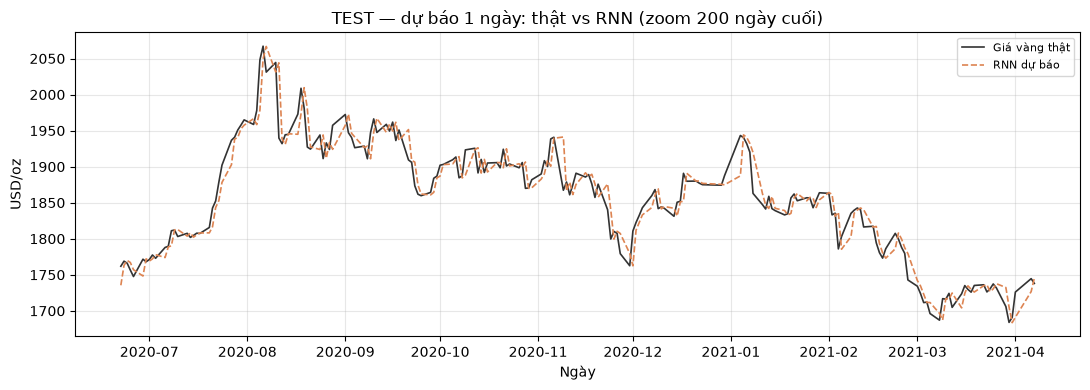

In [18]:
test_dates = test_df.index[L_WINDOW:]
fig, ax = plt.subplots(figsize=(11, 4))
zoom = slice(-200, None)
ax.plot(test_dates[zoom], y_true_real[zoom], color="#333333", lw=1.2, label="Giá vàng thật")
ax.plot(test_dates[zoom], pred_real[zoom], color="#DD8452", lw=1.2, ls="--", label="RNN dự báo")
ax.set_ylabel("USD/oz"); ax.set_xlabel("Ngày")
ax.set_title("TEST — dự báo 1 ngày: thật vs RNN (zoom 200 ngày cuối)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-07-predictions.png", bbox_inches="tight")
plt.show()

 ### §6.2 Dự báo đệ quy 30 ngày — `metals-08-forecast.png`

 **Hàm `recursive_forecast`** — vai trò: **đa bước tự hồi trên Δ** — từ cửa sổ 30 ngày (kết
 thúc 30 ngày trước hết test), mỗi bước dự báo Δ̂ (chặn guard ±3σ), **cộng dồn** vào giá vàng
 scaled gần nhất theo $z_{t+1} = z_t + \hat{\Delta}$, lấp $z_{t+1}$ vào cửa sổ rồi trượt 1
 bước, lặp `steps=30`. **Giả định:** giá bạc giữ nguyên ở mức cuối (mô hình chỉ dự báo vàng) —
 suy giảm được nêu rõ.
 - **Input:** mảng đặc trưng scaled (n, 2), số bước, biên guard — **Output:** giá vàng
 USD/oz của `steps` ngày dự báo (so sánh với 30 ngày thật cuối test).
 - **Lưu ý trung thực:** mỗi bước tự nuôi đầu ra của mình nên **lỗi tích luỹ**; guard ±3σ giữ
   từng bước trong biên biến động thực tế nên đường không bùng nổ vô hạn, nhưng Δ̂ có xu hướng
   nhỏ dần (mean reversion) → đường dự báo **đi ngang**: trên đoạn test cuối đang có xu hướng
   mạnh thì RMSE đệ quy vẫn lớn (bắt xu hướng đa bước là bài khó hơn hẳn dự báo 1 bước).

Dự báo đệ quy 30 ngày cuối test: RMSE 83.75 USD | MAPE 4.63%


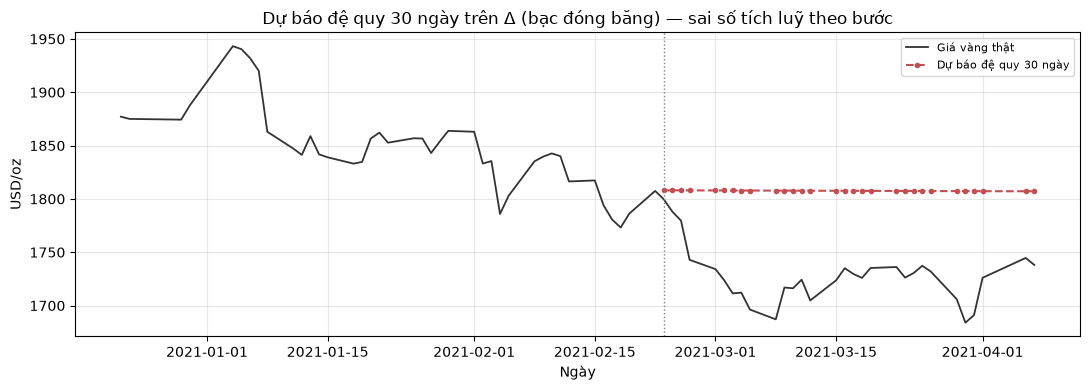

In [19]:
def recursive_forecast(model, features_scaled, L, steps, bound):
    """Đệ quy steps bước trên Δ: z_(t+1) = z_t + clip(Δ̂, ±3σ); bạc đóng băng mức cuối."""
    start = len(features_scaled) - steps - L
    window = features_scaled[start:start + L].copy()
    silver_frozen = window[-1, 1]                    # giả định bạc giữ mức cuối
    preds_scaled = []
    with torch.no_grad():
        for _ in range(steps):
            x = torch.from_numpy(window[np.newaxis, ...].astype(np.float32))
            delta = float(np.clip(model(x).item(), -bound, bound))   # guard Δ̂ trong ±3σ
            next_gold = window[-1, 0] + delta        # cộng dồn Δ̂ vào giá scaled gần nhất
            preds_scaled.append(next_gold)
            new_row = np.array([next_gold, silver_frozen], dtype=np.float32)
            window = np.vstack([window[1:], new_row])  # trượt cửa sổ 1 bước
    return inverse_gold(np.array(preds_scaled), scaler)


STEPS = 30
forecast = recursive_forecast(model, test_s, L_WINDOW, STEPS, DELTA_BOUND)
actual_last = gold_test_real[-STEPS:]
fc_metrics = evaluate_forecast(actual_last, forecast)
print("Dự báo đệ quy %d ngày cuối test: RMSE %.2f USD | MAPE %.2f%%"
      % (STEPS, fc_metrics["rmse"], fc_metrics["mape"]))

dates_fc = test_df.index[-(STEPS + 40):]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dates_fc, gold_test_real[-(STEPS + 40):], color="#333333", lw=1.3, label="Giá vàng thật")
ax.plot(test_df.index[-STEPS:], forecast, color="#C44E52", lw=1.5, ls="--", marker="o",
        ms=3, label="Dự báo đệ quy %d ngày" % STEPS)
ax.axvline(test_df.index[-STEPS], color="gray", ls=":", lw=1)
ax.set_ylabel("USD/oz"); ax.set_xlabel("Ngày")
ax.set_title("Dự báo đệ quy 30 ngày trên Δ (bạc đóng băng) — sai số tích luỹ theo bước")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-08-forecast.png", bbox_inches="tight")
plt.show()

 ### §6.3 Scatter thật vs dự báo — `metals-09-scatter.png`
 Điểm nằm sát đường chéo $y = x$ → dự báo khớp mặt bằng giá; sai lệch chủ yếu là
 độ trễ 1 ngày (đặc trưng mô hình one-step trên random walk).

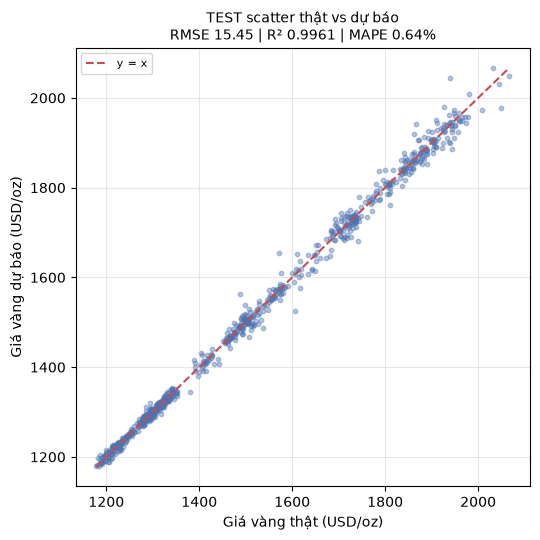

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true_real, pred_real, s=10, alpha=0.4, color="#4C72B0")
lo, hi = y_true_real.min(), y_true_real.max()
ax.plot([lo, hi], [lo, hi], color="#C44E52", lw=1.5, ls="--", label="y = x")
ax.set_xlabel("Giá vàng thật (USD/oz)"); ax.set_ylabel("Giá vàng dự báo (USD/oz)")
ax.set_title("TEST scatter thật vs dự báo\nRMSE %.2f | R² %.4f | MAPE %.2f%%"
             % (m_model["rmse"], m_model["r2"], m_model["mape"]), fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-09-scatter.png", bbox_inches="tight")
plt.show()

 ---
 ## §7. Lưu model + meta JSON

 Lưu `state_dict` + config vào `../model/metals_rnn_pytorch.pth`; toàn bộ cấu hình, chỉ số
 test (model + naive), lịch sử loss, danh sách figure vào `../model/metals_pytorch_meta.json`
 (notebook Keras ở app sau sẽ đọc file này để lập bảng so sánh 3 hàng).

In [21]:
model_path = MODEL / "metals_rnn_pytorch.pth"
meta_path = MODEL / "metals_pytorch_meta.json"
torch.save({"state_dict": model.state_dict(),
            "config": {"window": L_WINDOW, "hidden": 128, "lr": 1e-3, "batch": BATCH,
                       "features": ["gold", "silver"],
                       "target": "delta_residual (z[i,0]-z[i-1,0], scaled)",
                       "window_start": WINDOW_START}}, model_path)

meta = {
    "model": "metals_rnn_pytorch",
    "framework": "pytorch",
    "dataset": "Kaggle lbronchal/gold-and-silver-prices-dataset (1968-2021)",
    "config": {"window": L_WINDOW, "hidden": 128, "epochs_max": 30, "patience": 4,
               "epochs_run": history["epochs_run"], "best_epoch": history["best_epoch"],
               "lr": 1e-3, "batch": BATCH, "split": [n_train, n_val - n_train, n - n_val],
               "scaler": "MinMaxScaler fit trên train", "seed": RANDOM_SEED,
               "target": "delta_residual (z[i,0]-z[i-1,0], scaled)",
               "delta_guard": {"rule": "clip nhãn y và dự báo Δ̂ trong ±3σ(Δ train)",
                               "sigma_scaled": round(SIGMA_DELTA, 6),
                               "bound_usd": round(BOUND_USD, 3)}},
    "metrics": {"rmse": m_model["rmse"], "mae": m_model["mae"], "mape": m_model["mape"],
                "r2": m_model["r2"], "directional_acc": d_model,
                "naive": {"rmse": m_naive["rmse"], "mae": m_naive["mae"], "mape": m_naive["mape"],
                          "r2": m_naive["r2"], "directional_acc": d_naive},
                "recursive_30d": fc_metrics,
                "prev_level_metrics": {"rmse": PREV_LEVEL["rmse"], "mape": PREV_LEVEL["mape"],
                                       "note": "bản dự báo mức giá scaled trước nâng cấp (hidden 64)"}},
    "history": {"train_loss": history["train_loss"], "val_loss": history["val_loss"]},
    "model_file": str(model_path),
    "figures": ["metals-01-history.png", "metals-02-returns.png", "metals-03-correlation.png",
                "metals-04-monthly.png", "metals-05-split.png", "metals-06-loss.png",
                "metals-07-predictions.png", "metals-08-forecast.png", "metals-09-scatter.png"],
}
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print("Đã lưu:", model_path)
print("Đã lưu:", meta_path)

Đã lưu: ..\model\metals_rnn_pytorch.pth
Đã lưu: ..\model\metals_pytorch_meta.json


 ---
 ## Kết luận

 | Bước | Kết quả chính |
 |---|---|
 | EDA | Regime change 1971 (hết neo 35 USD) → chọn cửa sổ 2000+ (5.332 ngày); lợi suất đuôi dày; tương quan vàng–bạc ~0.7 nhưng không ổn định |
 | Preprocess | Chronological 70/15/15 (3.732/800/800 ngày → 3.702/770/770 cửa sổ), MinMax fit trên train, L=30, [gold, silver] → **nhãn Δ phần dư clip ±3σ(Δ train)** |
 | Model | Elman RNN **128 ẩn, 17.025 tham số**, công thức $h_t=\tanh(Wx_t+Uh_{t-1}+b_h)$, $\hat{\Delta}=Vh_T+b_y$ |
 | Train | MSE (trên Δ scaled) + Adam 1e-3, batch 64, EarlyStopping patience 4 + restore best (≤30 epochs) |
 | Test | **Bản Δ thắng baseline naive**: RMSE ~15,4 < naive ~15,5 USD (bản mức giá cũ 33,4 ≈ 2,2×naive); MAPE ~0,64%; DirAcc ~53% > naive quán tính ~51% (xem bảng §5) |

 **Thông điệp trung thực:** đổi mục tiêu từ *mức giá* sang *phần dư Δ* (cộng guard ±3σ) đã đảo
 chiều kết luận — RNN 1 tầng giờ **khớp/nhỉnh hơn baseline naive** về RMSE và có chút tín hiệu
 hướng (DirAcc ~53%), nhưng lợi thế mỏng: bản chất dự báo giá 1 ngày của chuỗi gần random walk
 vẫn rất khó; dự báo đệ quy đa bước tích luỹ sai số nhanh. Notebook Keras (02) lặp lại đúng
 quy trình Δ này để so sánh hai framework trên cùng dữ liệu.

In [22]:
print("Tổng kết (PyTorch, bản Δ residual): epochs chạy %d | best epoch %d | RMSE %.2f (naive %.2f) | MAPE %.3f%% | DirAcc %.2f%% (naive quán tính %.2f%%) | bản mức giá cũ RMSE %.2f"
      % (history["epochs_run"], history["best_epoch"], m_model["rmse"], m_naive["rmse"],
         m_model["mape"], d_model, d_naive, PREV_LEVEL["rmse"]))

Tổng kết (PyTorch, bản Δ residual): epochs chạy 7 | best epoch 3 | RMSE 15.45 (naive 15.48) | MAPE 0.644% | DirAcc 53.45% (naive quán tính 51.30%) | bản mức giá cũ RMSE 33.37
